In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

In [2]:
data = np.load(r'C:\Users\rafin\Desktop\HSIC\Ripeness\Datasets\CNN_Datasets\Kiwi_VIS\Kiwi_Ripeness_VIS_train.npy', allow_pickle=True)
labels = np.load(r'C:\Users\rafin\Desktop\HSIC\Ripeness\Datasets\CNN_Datasets\Kiwi_VIS\Kiwi_Ripeness_VIS_train_labels.npy', allow_pickle=True)

data.shape, labels.shape

((1390, 32, 32, 224), (1390,))

In [3]:
mean = data.mean(axis=(0, 1, 2), keepdims=True)
std_dev = data.std(axis=(0, 1, 2), keepdims=True)

In [4]:
np.save(r'C:\Users\rafin\Desktop\HSIC\Ripeness\Datasets\CNN_Datasets\Kiwi_VIS\PCA\PCA_comp\mean_std\Kiwi_VIS_mean.npy', mean)
np.save(r'C:\Users\rafin\Desktop\HSIC\Ripeness\Datasets\CNN_Datasets\Kiwi_VIS\PCA\PCA_comp\mean_std\Kiwi_VIS_std.npy', std_dev)

In [5]:
# Z-score normalization
data = (data - mean) / std_dev

print("Dataset shape:", data.shape)

Dataset shape: (1390, 32, 32, 224)


In [6]:
# PCA START
hsi_image_train = data

# Reshape
hsi_reshaped_train = hsi_image_train.reshape(-1, 224)

In [7]:
# Apply PCA
pca = PCA()
hsi_train_pca = pca.fit_transform(hsi_reshaped_train)

explained_variance = pca.explained_variance_ratio_
cumulative_explained_variance = np.cumsum(explained_variance)

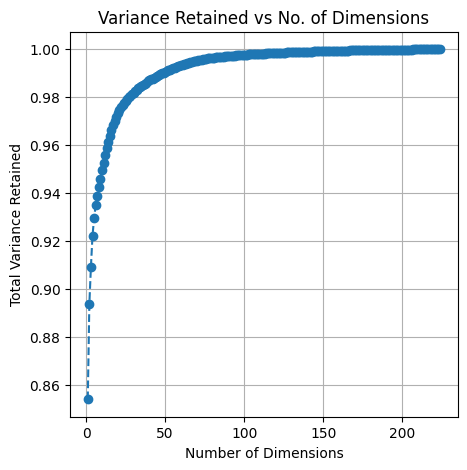

In [8]:
plt.figure(figsize=(5, 5))
plt.plot(range(1, len(cumulative_explained_variance) + 1), cumulative_explained_variance, marker='o', linestyle='--')
plt.xlabel('Number of Dimensions')
plt.ylabel('Total Variance Retained')
plt.title('Variance Retained vs No. of Dimensions')
plt.grid()
plt.show()

In [9]:
# No. of Dimensions that retains 99% variance:
optimal_components = np.argmax(cumulative_explained_variance >= 0.999) + 1 
print(f"Number of Dimensions to retain 99% variance: {optimal_components}")

# Apply PCA with optimal components
pca = PCA(n_components=optimal_components)
X_train_PCA = pca.fit_transform(hsi_reshaped_train)

X_train_PCA.shape

Number of Dimensions to retain 99% variance: 142


(1423360, 142)

In [11]:
# Save PCA components and mean
np.save(r'C:\Users\rafin\Desktop\HSIC\Ripeness\Datasets\CNN_Datasets\Kiwi_VIS\PCA\PCA_comp\Kiwi_VIS_pca_comp.npy', pca.components_)
np.save(r'C:\Users\rafin\Desktop\HSIC\Ripeness\Datasets\CNN_Datasets\Kiwi_VIS\PCA\PCA_comp\Kiwi_VIS_pca_mean.npy', pca.mean_)

In [12]:
# Reshape back to the spatial dimensions
data_train = X_train_PCA.reshape(1390, 32, 32, optimal_components)

data_train.shape

(1390, 32, 32, 142)

In [13]:
np.save(r'C:\Users\rafin\Desktop\HSIC\Ripeness\Datasets\CNN_Datasets\Kiwi_VIS\PCA\Kiwi_VIS_PCA_train.npy', data_train)

In [ ]:
# LOAD PCA DATA
data_train = np.load(r'C:\Users\rafin\Desktop\HSIC\Ripeness\Datasets\CNN_Datasets\Avacado_VIS\PCA\Avocado_VIS_PCA_train.npy')
train_labels = np.load(r'C:\Users\rafin\Desktop\HSIC\Ripeness\Datasets\CNN_Datasets\Avacado_VIS\Avocado_Ripeness_VIS_train_labels.npy')

print(data_train.shape, train_labels.shape)

APPLY PCA TO TEST and val

In [21]:
# Load test data
test_data = np.load(r'C:\Users\rafin\Desktop\HSIC\Ripeness\Datasets\CNN_Datasets\Kiwi_VIS\Kiwi_Ripeness_VIS_test.npy', allow_pickle=True)

# Load training normalization parameters
train_mean = np.load(r'C:\Users\rafin\Desktop\HSIC\Ripeness\Datasets\CNN_Datasets\Kiwi_VIS\PCA\PCA_comp\mean_std\Kiwi_VIS_mean.npy')
train_std = np.load(r'C:\Users\rafin\Desktop\HSIC\Ripeness\Datasets\CNN_Datasets\Kiwi_VIS\PCA\PCA_comp\mean_std\Kiwi_VIS_std.npy')

# Load PCA parameters from training
pca_components = np.load(r'C:\Users\rafin\Desktop\HSIC\Ripeness\Datasets\CNN_Datasets\Kiwi_VIS\PCA\PCA_comp\Kiwi_VIS_pca_comp.npy')
pca_mean = np.load(r'C:\Users\rafin\Desktop\HSIC\Ripeness\Datasets\CNN_Datasets\Kiwi_VIS\PCA\PCA_comp\Kiwi_VIS_pca_mean.npy')

In [22]:
# Normalize test data using TRAINING'S mean and std
test_data_normalized = (test_data - train_mean) / train_std

In [23]:
# Reshape test data to 2D
num_test_samples = test_data.shape[0]
hsi_reshaped_test = test_data_normalized.reshape(num_test_samples * 32 * 32, 224)

In [24]:
# Apply PCA transformation
hsi_test_pca = (hsi_reshaped_test - pca_mean) @ pca_components.T

# Reshape back to 4D (preserve spatial dimensions)
optimal_components = pca_components.shape[0]  # Get from component shape
test_data_pca = hsi_test_pca.reshape(num_test_samples, 32, 32, optimal_components)

In [25]:
# Save transformed test data
np.save(r'C:\Users\rafin\Desktop\HSIC\Ripeness\Datasets\CNN_Datasets\Kiwi_VIS\PCA\Kiwi_VIS_PCA_test.npy', test_data_pca)

In [26]:
test_data_pca.shape

(240, 32, 32, 142)